<a href="https://colab.research.google.com/github/trialdyk/PCVK-Ganjil-2026/blob/main/Week1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Praktikum D2 - Pengolahan Citra Digital
Membaca citra via URL, manipulasi channel warna, serta manipulasi piksel manual.

### Langkah 1: Import Library

In [1]:
import numpy as np
import pandas as pd
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
from skimage import transform
from PIL import Image
import matplotlib.pylab as plt

### Langkah 2: Membaca dan Menampilkan Citra dari URL

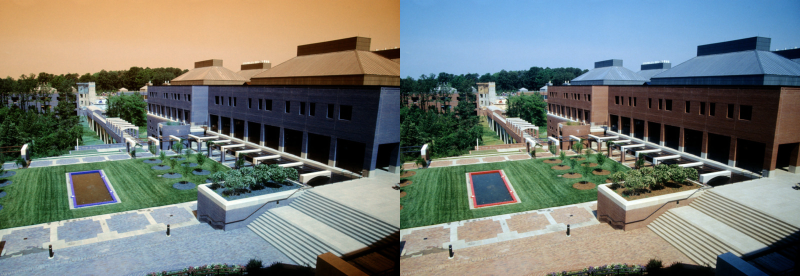

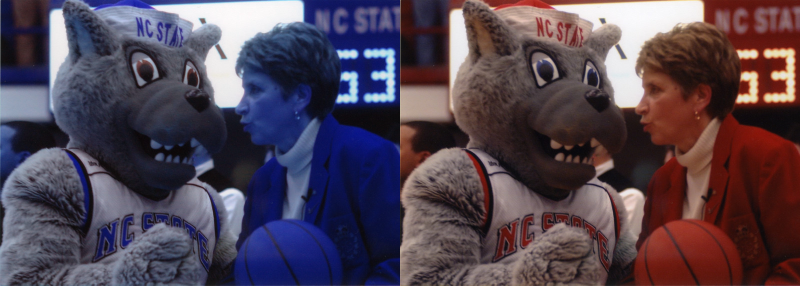



Gagal memuat URL: https://placekitten.com/800/571 -> HTTP Error 521: <none>


In [2]:
urls = [
    "https://iiif.lib.ncsu.edu/iiif/0052574/full/800,/0/default.jpg",
    "https://iiif.lib.ncsu.edu/iiif/0016007/full/800,/0/default.jpg",
    "https://placekitten.com/800/571"
]

for url in urls:
    try:
        image = io.imread(url)
        # Resize ukuran citra menjadi setengahnya
        image = cv.resize(image, (0, 0), fx=0.5, fy=0.5)
        # Konversi warna ke RGB
        image_2 = cv.cvtColor(image, cv.COLOR_BGR2RGB)
        # Gabungkan secara horizontal
        final_frame = cv.hconcat((image, image_2))
        cv2_imshow(final_frame)
        print('\n')
    except Exception as e:
        print(f"Gagal memuat URL: {url} -> {e}")

### Langkah 3: Melihat Dimensi Citra

resolusi image: tinggi x lebar = 286 x 400


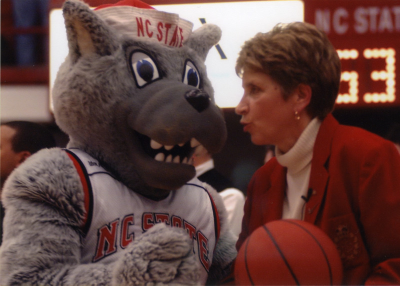

In [3]:
# Gunakan citra terakhir dari perulangan
tinggi = image_2.shape[0]
lebar = image_2.shape[1]
print("resolusi image: tinggi x lebar =", tinggi, "x", lebar)
cv2_imshow(image_2)

### Langkah 4: Modifikasi Piksel (Garis Horizontal Penuh)

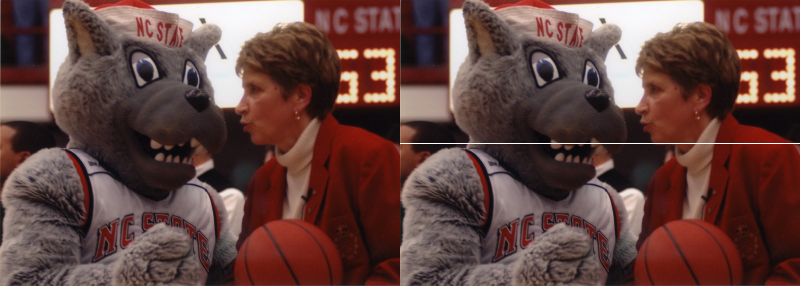

In [4]:
image_line = image_2.copy()

for y in range(lebar):
    image_line[int(tinggi / 2), y] = [255, 255, 255]

final_frame = cv.hconcat((image_2, image_line))
cv2_imshow(final_frame)

### Tugas Praktikum D2 - Nomor 2: Garis Vertikal dan Menyilang Diagonal

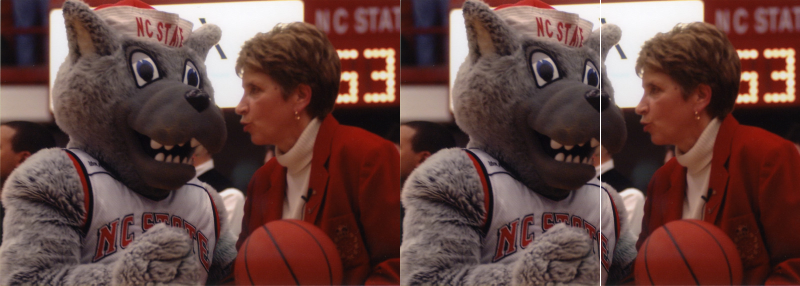

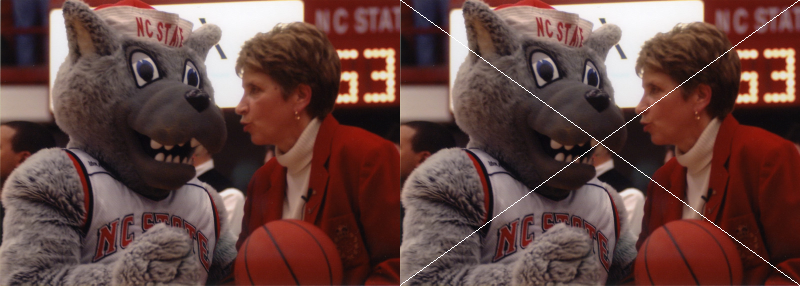

In [5]:
tugas2_vertikal = image_2.copy()
# Garis vertikal di tengah citra
for x in range(tinggi):
    tugas2_vertikal[x, int(lebar / 2)] = [255, 255, 255]

frame_vertikal = cv.hconcat((image_2, tugas2_vertikal))
cv2_imshow(frame_vertikal)

tugas2_diagonal = image_2.copy()
# Garis diagonal menyilang penuh (membentuk huruf X)
for y in range(lebar):
    x1 = int(y * (tinggi - 1) / (lebar - 1))
    x2 = int((lebar - 1 - y) * (tinggi - 1) / (lebar - 1))
    tugas2_diagonal[x1, y] = [255, 255, 255]
    tugas2_diagonal[x2, y] = [255, 255, 255]

frame_diagonal = cv.hconcat((image_2, tugas2_diagonal))
cv2_imshow(frame_diagonal)

### Tugas Praktikum D2 - Nomor 3: Garis Horizontal Putih dengan Panjang Tertentu

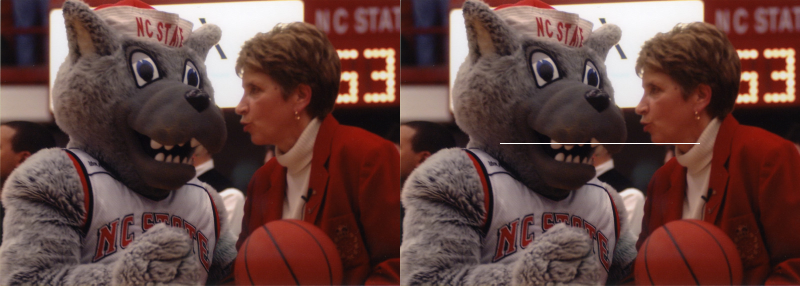

In [6]:
tugas3_img = image_2.copy()

# Garis horizontal di tengah dengan batas koordinat tertentu
start_x = int(lebar * 0.25)
end_x = int(lebar * 0.75)
mid_y = int(tinggi / 2)

for y in range(start_x, end_x):
    tugas3_img[mid_y, y] = [255, 255, 255]

frame_tugas3 = cv.hconcat((image_2, tugas3_img))
cv2_imshow(frame_tugas3)

### Tugas Praktikum D2 - Nomor 4: Kotak Kumpulan Piksel Putih di Sembarang Tempat

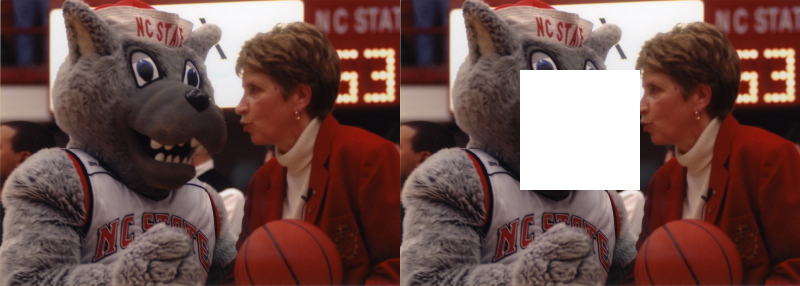

In [7]:
tugas4_img = image_2.copy()

# Menentukan area bounding box sembarang
kotak_y_start = 70
kotak_y_end = 190
kotak_x_start = 120
kotak_x_end = 240

# Mengisi area dengan piksel putih melalui array slicing
tugas4_img[kotak_y_start:kotak_y_end, kotak_x_start:kotak_x_end] = [255, 255, 255]

frame_tugas4 = cv.hconcat((image_2, tugas4_img))
cv2_imshow(frame_tugas4)